### Import Libaries


In [32]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt  
import seaborn as sns  

In [33]:
df = pd.read_csv("BMW sales data (2010-2024) (1).csv")
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [34]:
print("The info of the dataset is as follows:", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB
The info of the dataset is as follows: None


In [35]:
print(df.describe())

               Year  Engine_Size_L     Mileage_KM      Price_USD  Sales_Volume
count  50000.000000   50000.000000   50000.000000   50000.000000  50000.000000
mean    2017.015700       3.247180  100307.203140   75034.600900   5067.514680
std        4.324459       1.009078   57941.509344   25998.248882   2856.767125
min     2010.000000       1.500000       3.000000   30000.000000    100.000000
25%     2013.000000       2.400000   50178.000000   52434.750000   2588.000000
50%     2017.000000       3.200000  100388.500000   75011.500000   5087.000000
75%     2021.000000       4.100000  150630.250000   97628.250000   7537.250000
max     2024.000000       5.000000  199996.000000  119998.000000   9999.000000


In [36]:
# drop duplicates
df.drop_duplicates(inplace=True)

### feature enginerring

In [37]:
# add total price column
df['Total Price'] = df['Price_USD'] * df['Sales_Volume']


In [38]:
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Total Price
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,819542000
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,271562732
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low,792175410
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low,246749637
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low,153685840


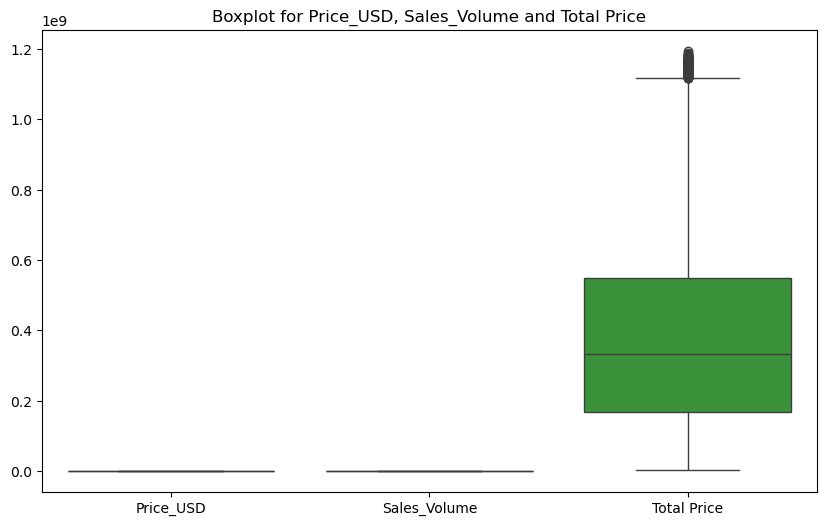

In [39]:
# checking outliers using boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['Price_USD', 'Sales_Volume', 'Total Price']])
plt.title('Boxplot for Price_USD, Sales_Volume and Total Price')
plt.show()

In [40]:
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Total Price
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High,819542000
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low,271562732
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low,792175410
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low,246749637
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low,153685840


In [41]:
# label encoder of sales classification
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sales_Classification'] = le.fit_transform(df['Sales_Classification'])
print(df.head())
print("sales classification labels:", le.classes_)

      Model  Year         Region  Color Fuel_Type Transmission  Engine_Size_L  \
0  5 Series  2016           Asia    Red    Petrol       Manual            3.5   
1        i8  2013  North America    Red    Hybrid    Automatic            1.6   
2  5 Series  2022  North America   Blue    Petrol    Automatic            4.5   
3        X3  2024    Middle East   Blue    Petrol    Automatic            1.7   
4  7 Series  2020  South America  Black    Diesel       Manual            2.1   

   Mileage_KM  Price_USD  Sales_Volume  Sales_Classification  Total Price  
0      151748      98740          8300                     0    819542000  
1      121671      79219          3428                     1    271562732  
2       10991     113265          6994                     1    792175410  
3       27255      60971          4047                     1    246749637  
4      122131      49898          3080                     1    153685840  
sales classification labels: ['High' 'Low']


In [42]:
# le encoding of fuel_type
df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Total Price
0,5 Series,2016,Asia,Red,3,Manual,3.5,151748,98740,8300,0,819542000
1,i8,2013,North America,Red,2,Automatic,1.6,121671,79219,3428,1,271562732
2,5 Series,2022,North America,Blue,3,Automatic,4.5,10991,113265,6994,1,792175410
3,X3,2024,Middle East,Blue,3,Automatic,1.7,27255,60971,4047,1,246749637
4,7 Series,2020,South America,Black,0,Manual,2.1,122131,49898,3080,1,153685840


In [43]:
print("Fuel Type labels:", le.classes_)

Fuel Type labels: ['Diesel' 'Electric' 'Hybrid' 'Petrol']


C:\Users\Asus\AppData\Local\Temp\ipykernel_20132\2531022959.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Region', y='Sales_Volume', data=df, ci=None, palette='viridis')
C:\Users\Asus\AppData\Local\Temp\ipykernel_20132\2531022959.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Region', y='Sales_Volume', data=df, ci=None, palette='viridis')
C:\Users\Asus\AppData\Local\Temp\ipykernel_20132\2531022959.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Model', y='Sales_Volume', data=df, ci=None, palette='coolwarm')
C:\Users\Asus\AppData\Local\Temp\ipykernel_20132\2531022959.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. As

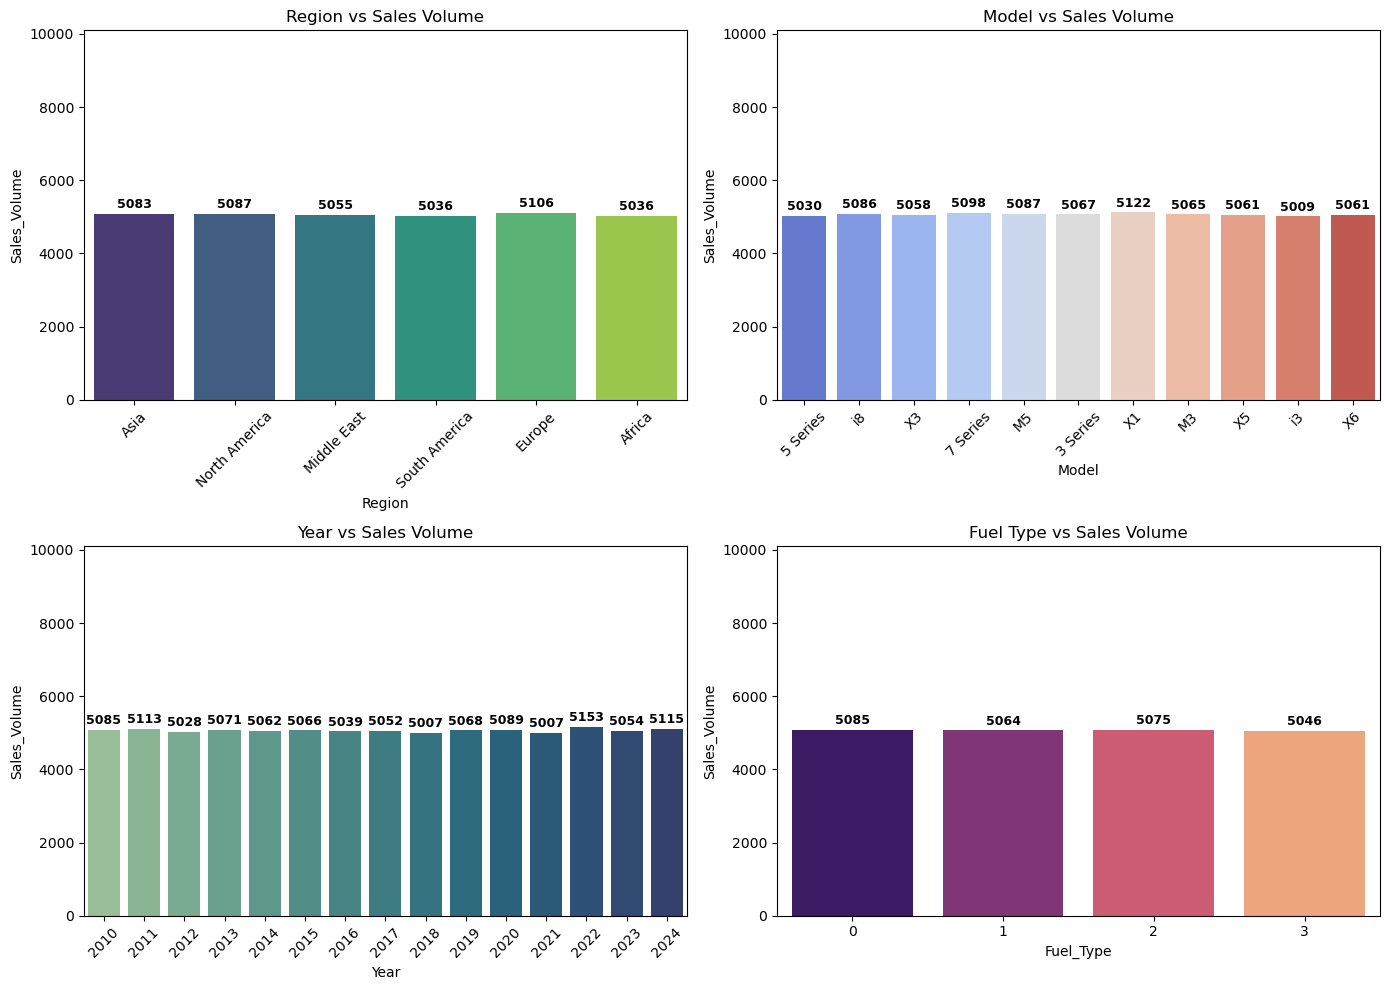

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

# --- Region ---
plt.subplot(2,2,1)
ax = sns.barplot(x='Region', y='Sales_Volume', data=df, ci=None, palette='viridis')
plt.title('Region vs Sales Volume')
plt.xticks(rotation=45)
plt.ylim(df['Sales_Volume'].min()-100, df['Sales_Volume'].max()+100)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=9, fontweight='bold', padding=2)

# --- Model ---
plt.subplot(2,2,2)
ax = sns.barplot(x='Model', y='Sales_Volume', data=df, ci=None, palette='coolwarm')
plt.title('Model vs Sales Volume')
plt.xticks(rotation=45)
plt.ylim(df['Sales_Volume'].min()-100, df['Sales_Volume'].max()+100)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=9, fontweight='bold', padding=2)

# --- Year ---
plt.subplot(2,2,3)
ax = sns.barplot(x='Year', y='Sales_Volume', data=df, ci=None, palette='crest')
plt.title('Year vs Sales Volume')
plt.xticks(rotation=45)
plt.ylim(df['Sales_Volume'].min()-100, df['Sales_Volume'].max()+100)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=9, fontweight='bold', padding=2)

# --- Fuel Type ---
plt.subplot(2,2,4)
ax = sns.barplot(x='Fuel_Type', y='Sales_Volume', data=df, ci=None, palette='magma')
plt.title('Fuel Type vs Sales Volume')
plt.ylim(df['Sales_Volume'].min()-100, df['Sales_Volume'].max()+100)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=9, fontweight='bold', padding=2)

plt.tight_layout()
plt.show()


In [47]:
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Total Price
0,5 Series,2016,Asia,Red,3,Manual,3.5,151748,98740,8300,0,819542000
1,i8,2013,North America,Red,2,Automatic,1.6,121671,79219,3428,1,271562732
2,5 Series,2022,North America,Blue,3,Automatic,4.5,10991,113265,6994,1,792175410
3,X3,2024,Middle East,Blue,3,Automatic,1.7,27255,60971,4047,1,246749637
4,7 Series,2020,South America,Black,0,Manual,2.1,122131,49898,3080,1,153685840


In [53]:
# find which region has highest sale volume and in which year with model
max_sales = df['Sales_Volume'].max()
max_sales_record = df[df['Sales_Volume'] == max_sales]
print("Record with highest sales volume:")
max_sales_record


Record with highest sales volume:


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Total Price
13521,7 Series,2024,Europe,Silver,0,Automatic,3.7,50463,71167,9999,0,711598833
27113,X3,2011,Africa,Silver,1,Manual,2.0,123193,79124,9999,0,791160876
38529,M3,2022,Europe,Red,3,Manual,4.8,43988,38126,9999,0,381221874
39518,3 Series,2017,North America,Black,1,Automatic,2.7,35357,64641,9999,0,646345359
47953,5 Series,2024,South America,White,1,Manual,2.5,52062,88572,9999,0,885631428


In [54]:
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Total Price
0,5 Series,2016,Asia,Red,3,Manual,3.5,151748,98740,8300,0,819542000
1,i8,2013,North America,Red,2,Automatic,1.6,121671,79219,3428,1,271562732
2,5 Series,2022,North America,Blue,3,Automatic,4.5,10991,113265,6994,1,792175410
3,X3,2024,Middle East,Blue,3,Automatic,1.7,27255,60971,4047,1,246749637
4,7 Series,2020,South America,Black,0,Manual,2.1,122131,49898,3080,1,153685840


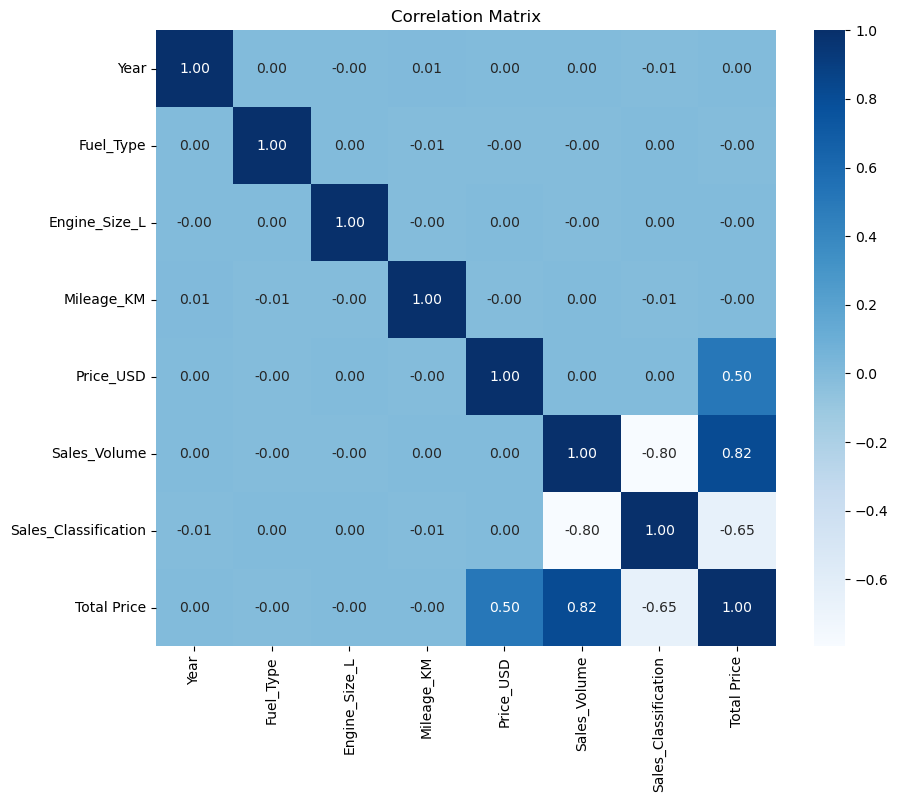

In [56]:
plt.figure(figsize=(10,8))

# select only numeric columns
corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


In [60]:
# model prepared
from sklearn.model_selection import train_test_split
x = df.drop(columns=['Sales_Classification'] , axis=1)
y = df['Sales_Classification']
x_train , x_test , y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [62]:
x_train.dtypes


Model             object
Year               int64
Region            object
Color             object
Fuel_Type          int64
Transmission      object
Engine_Size_L    float64
Mileage_KM         int64
Price_USD          int64
Sales_Volume       int64
Total Price        int64
dtype: object

In [63]:
from sklearn.preprocessing import LabelEncoder

# Make a copy (optional)
x_train_encoded = x_train.copy()
x_test_encoded = x_test.copy()

# Encode all categorical (object) columns
label_encoders = {}
for col in x_train_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    x_train_encoded[col] = le.fit_transform(x_train_encoded[col])
    x_test_encoded[col] = le.transform(x_test_encoded[col])  # use same encoder
    label_encoders[col] = le


In [64]:
y_train = y_train.values.ravel()


In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    max_leaf_nodes=20
)

rf_model.fit(x_train_encoded, y_train)
print("✅ Model trained successfully!")

y_pred = rf_model.predict(x_test_encoded)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


✅ Model trained successfully!

Accuracy: 1.0

Confusion Matrix:
 [[3032    0]
 [   0 6968]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3032
           1       1.00      1.00      1.00      6968

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [67]:
x_train_encoded.dtypes

Model              int64
Year               int64
Region             int64
Color              int64
Fuel_Type          int64
Transmission       int64
Engine_Size_L    float64
Mileage_KM         int64
Price_USD          int64
Sales_Volume       int64
Total Price        int64
dtype: object